Do stable molecular expression clusters exist within the 122 cancer samples?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snb
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [2]:
#Cancer only dataset creation
df = pd.read_csv("tissue_dataset.csv")
df_cancer = df[df["target"] == 1].copy()
df_cancer.shape

(122, 1928)

In [3]:
#Feature seperation
X_cancer = df_cancer.drop(columns = ["target", "target_actual"])
X_cancer.shape

(122, 1926)

In [4]:
#Standardization
scaler = StandardScaler()
X_cancer_scaled = scaler.fit_transform(X_cancer)
X_cancer.shape

(122, 1926)

In [5]:
#PCA 
pca = PCA(
    n_components = 0.90,
    random_state = 42
)

X_cancer_pca = pca.fit_transform(X_cancer_scaled)
X_cancer_pca.shape, pca.explained_variance_ratio_.sum()

((122, 31), np.float64(0.9009192609671703))

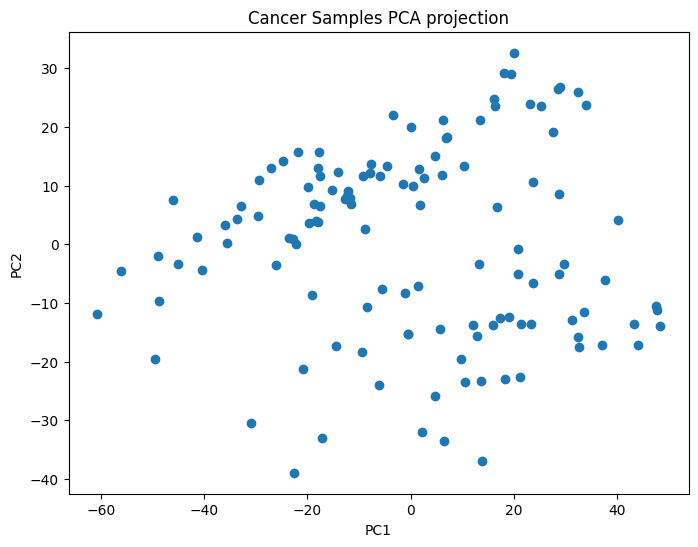

In [6]:
#PCA visulaization
pca_vis = pd.DataFrame(
    X_cancer_pca[:, :2],
    columns = ["PC1", "PC2"]
)

plt.figure(figsize = (8,6))

plt.scatter(
    pca_vis["PC1"],
    pca_vis["PC2"]
)

plt.title("Cancer Samples PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [7]:
#GMM for k = 2 to 15
results = []

for k in range (2,16):
    gmm = GaussianMixture(
        n_components = k,
        random_state = 42
    )

    labels = gmm.fit_predict(X_cancer_pca)
    results.append([
        k,
        silhouette_score(
            X_cancer_pca,
            labels
        ),
        gmm.aic(X_cancer_pca),
        gmm.bic(X_cancer_pca)
    ])

results_df = pd.DataFrame(
    results, 
    columns = ["Components", "Silhouette", "AIC", "BIC"]
)

In [8]:
#Hierarchical Clustering for k = 2 to 15
hc_results = []
for k in range (2,16):
    hc = AgglomerativeClustering(
        n_clusters = k,
        linkage = "ward"
    )
    labels = hc.fit_predict(X_cancer_pca)

    score = silhouette_score(X_cancer_pca, labels)
    hc_results.append([k, score])
    hc_results_df = pd.DataFrame(
        hc_results,
        columns = [
            "Components",
            "Silhouette"
        ]
    )


In [9]:
gmm = GaussianMixture(
    n_components=6,
    random_state=42
)

cluster_labels = gmm.fit_predict(X_cancer_pca)
print("GMM: \n", pd.Series(cluster_labels).value_counts().sort_index())
df_cancer["GMM_Cluster"] = cluster_labels
df_cancer.to_csv(
    "cancer_dataset.csv",
    index=False
)

GMM: 
 0    25
1    24
2    21
3    33
4    14
5     5
Name: count, dtype: int64


In [10]:
hc = AgglomerativeClustering(
    n_clusters=9,
    linkage="ward"
)

hc_labels = hc.fit_predict(X_cancer_pca)

print("HC: \n", pd.Series(hc_labels).value_counts().sort_index())

HC: 
 0    22
1    24
2     9
3    13
4    25
5    14
6     3
7     8
8     4
Name: count, dtype: int64


## Conclusion

To investigate potential molecular expression groups within breast cancer samples, clustering was performed on 122 cancer samples after PCA-based dimensionality reduction (31 principal components retaining ~90% variance).

Gaussian Mixture Models (GMM) and Hierarchical Clustering produced similar maximum silhouette scores (~0.263), indicating the presence of weak but consistent internal structure. The GMM solution with 6 clusters was selected for further analysis due to its more balanced cluster distribution.

While the clustering results do not support claims of novel subtype discovery, they suggest the existence of distinct molecular expression patterns within the cancer cohort. Therefore, the identified GMM clusters will be used as exploratory molecular expression groups for downstream biomarker analysis.
